# Model-Based RL: Learned World Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand model-based RL
- Learn world models from experience
- Use learned models for planning
- Compare model-based vs model-free

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 1, lesson 04 "04. Linear Regression" — a world model is an ordinary supervised regressor fit to (state, action) → next state; what is new is not the fitting, it is planning against the model's predictions instead of against the real environment.

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 5**:
- Building model-based RL systems with learned world models

---

## Introduction

**Model-based RL** learns a model of the environment dynamics and uses it for planning, potentially achieving higher sample efficiency than model-free methods.

## Lesson Brief

This lesson introduces model-based RL, where the agent tries to learn how the environment works and then plan with that knowledge.

Students will see the full idea in simple form: collect experience, build a model, then use the model to choose actions.

Why this matters: model-based RL explains why some agents can learn faster from fewer environment interactions.

It also prepares students to think critically about model errors.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: MuZero shaved 4% off YouTube's bitrate

A **world model** is a learned model of the environment's dynamics that you can plan inside without
touching the real system. Two results make the case for why that matters.

**MuZero on YouTube.** MuZero learns a model of dynamics and reward *sufficient for planning* — it
never has to predict the raw next observation. In February 2022 DeepMind reported putting it into
production on YouTube's video compression: MuZero-RC replaces the VP9 codec's rate-control heuristic,
deciding the quantization parameter for each frame. "Since launching to production on a portion of
YouTube's live traffic, we've demonstrated an average **4% bitrate reduction** across a large, diverse
set of videos" — at comparable quality. Four percent of YouTube's traffic is a large number.

**DreamerV3.** Hafner, Pasukonis, Ba and Lillicrap ("Mastering diverse control tasks through world
models", *Nature* **640**, 647–653, 2025) trained an agent that learns a world model and then improves
its policy on *imagined* trajectories inside that model. One fixed configuration beat specialised
methods across more than 150 tasks — and, applied out of the box, it was the first algorithm to
**collect diamonds in Minecraft from scratch, without human data or curricula**.

**What goes wrong without this.** Model-free RL discards each transition after learning from it.
Model-based RL keeps it, builds a model, and then plans as many times as it likes at no further cost
in real experience. When real experience is the scarce resource — a robot, a codec running on live
traffic, a fusion reactor — that difference decides whether the project is possible.

And there is a benefit unique to this notebook: FrozenLake publishes its true dynamics, so you can do
something you almost never can in practice — measure *how wrong* your learned model still is.


## Recommended YouTube Video

To reinforce this lesson, watch **Yannic Kilcher - "Dreamer v2: Mastering Atari with Discrete World Models"**:
[Watch on YouTube](https://www.youtube.com/watch?v=o75ybZ-6Uu8)

Why this pick:
- strong paper-explainer style.
- Shows how world models support imagination-based learning and sample efficiency.
- Good match for students meeting model-based RL through modern world-model examples.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- World model: a learned model of environment behavior.
- Planning: reasoning before acting.
- Prediction error: model expectation versus reality.
- Imagined rollout: simulated future steps.
- Compounding error: small model mistakes that grow over many simulated steps.

### Quick Check
- What do we gain by learning a model?
- How can planning save real interaction?
- What risk comes from an inaccurate model?
- Why can long imagined rollouts become unreliable?

### Common Mistakes
- Thinking the model must be perfect.
- Ignoring accumulated model error.
- Confusing modeling the world with learning the policy.
- Assuming simulated planning is automatically trustworthy just because it is fast.


## Faster Learning Comes with a New Risk

Model-based RL is attractive because it can reuse experience more efficiently.
But the benefit comes with a new failure mode.

### The promise

If the agent learns a useful model of the world, it can plan in imagination instead of requiring every trial in the real environment.
That can greatly improve sample efficiency.

### The risk

If the model is wrong, planning can become confidently wrong too.
A small prediction error may not matter for one step, but over many imagined steps the error can accumulate.

### Teaching takeaway

Students should leave this notebook with both ideas together:

- model-based RL can learn faster
- model error can poison planning if we trust it too much

The point is not to worship sample efficiency alone.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- `gymnasium`'s `FrozenLake-v1` (4x4, **slippery**) — a standard benchmark whose *true* transition
  probabilities are published in `env.unwrapped.P`.
- Transitions collected by acting randomly in that real environment — no invented data anywhere.

**Outputs:** What you'll see when you run the cells

- A table and two figures showing, for four different data budgets: how far the learned model is
  from the true one, and how well a plan built from that learned model scores when it is actually
  run back in the environment.
- A printed row of the learned transition table next to the true one.

---

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries and open the real benchmark we will learn a model OF.
# WHY it matters: FrozenLake-v1 is one of the very few environments that hands you the TRUE
# transition probabilities (in env.unwrapped.P). That is a rare gift for teaching: we can learn
# a model from experience and then grade it against the exact answer, instead of just asserting
# that "the model got better".

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

# is_slippery=True: each action succeeds only about 1/3 of the time and slides sideways
# otherwise. A stochastic environment is the honest case - a model must learn a probability
# DISTRIBUTION over next states, not a single next state.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
N_STATES, N_ACTIONS = env.observation_space.n, env.action_space.n

print("Model-Based RL: Learned World Models")
print("=" * 60)
print("Environment:", env.spec.id, "| states:", N_STATES, "| actions:", N_ACTIONS)
print("\nThe loop we are about to run for real:")
print("  1. Collect  : act in the environment and record (s, a, r, s') transitions")
print("  2. Learn    : estimate P_hat(s'|s,a) and R_hat(s,a) by counting")
print("  3. Plan     : run value iteration INSIDE the learned model (zero new interactions)")
print("  4. Act      : run that plan back in the REAL environment and score it")
print("\nAnd because this environment publishes its true dynamics, we can also do")
print("something you normally cannot: measure how wrong the learned model still is.")

Model-Based RL: Learned World Models
Environment: FrozenLake-v1 | states: 16 | actions: 4

The loop we are about to run for real:
  1. Collect  : act in the environment and record (s, a, r, s') transitions
  2. Learn    : estimate P_hat(s'|s,a) and R_hat(s,a) by counting
  3. Plan     : run value iteration INSIDE the learned model (zero new interactions)
  4. Act      : run that plan back in the REAL environment and score it

And because this environment publishes its true dynamics, we can also do
something you normally cannot: measure how wrong the learned model still is.


## Worked Example: Learn a World Model From Real Experience, Then Plan With It

In model-based RL, the agent tries to answer this question:

`If I take action a in state s, what will probably happen next?`

Below, the agent explores the real `FrozenLake-v1` environment, counts the transitions it sees,
turns those counts into an estimated model `P_hat(s'|s,a)` and `R_hat(s,a)`, plans inside that
model with value iteration, and then runs the resulting plan back in the real environment.

This is the core loop of model-based RL: **experience -> model -> planning -> action**.

**What makes this lesson unusual:** FrozenLake publishes its true dynamics in `env.unwrapped.P`.
So we can grade the learned model against the exact answer, and grade the resulting plan against
the plan you would get if you already knew the environment perfectly. Both the promise (more data
-> better model -> better plan) and the risk (a model is only valid where you collected data) come
out as measured numbers rather than claims.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


Terminal tiles (holes + goal), where an episode ends: [5, 7, 11, 12, 15]
Ceiling: planning with the TRUE model scores 0.732 on 500 real episodes.
(Not 1.0 - the ice is slippery, so even a perfect plan sometimes slides into a hole.)

  real steps | model error (all) | model error (visited states) | policy matches | success
  -----------|-------------------|------------------------------|----------------|--------
         500 |             0.724 |                        0.598 |           9/16 |   0.000


        2000 |             0.503 |                        0.278 |          14/16 |   0.634


       10000 |             0.410 |                        0.142 |          15/16 |   0.576


       50000 |             0.354 |                        0.060 |          16/16 |   0.732


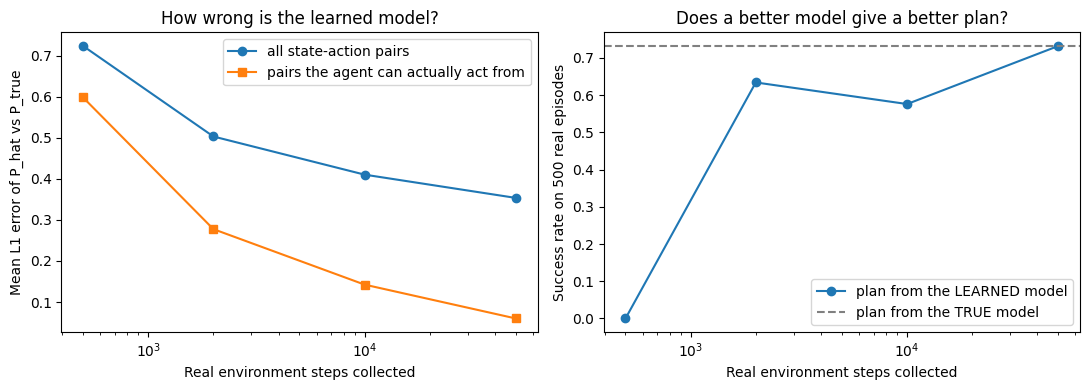


One concrete row of the model - P(s' | s=0, a=1 DOWN), after the largest budget:
  true    : {0: 0.333, 1: 0.333, 4: 0.333}
  learned : {0: 0.326, 1: 0.342, 4: 0.332}
  The agent was never told the ice slides. It counted, and the 1/3-1/3-1/3 fell out.

Reading the measured table:
- Model error on the states the agent can act from fell from 0.598
  to 0.060. More experience really does buy a better model.
- Success rate of the plan went from 0.000 to 0.732, against a
  ceiling of 0.732. Planning in a learned model is only as good as the model.
- But the trend is NOT monotonic: at 10000 steps the plan scored 0.576,
  BELOW the 0.634 it managed at 2000 steps - even though the model
  had got more accurate. A greedy plan is a discrete choice: one still-wrong action in
  one busy state can cost more than several small probability errors elsewhere. Model
  accuracy and policy quality are related, not the same number.
- The 'all pairs' error flattens near 0.354 and never reaches 0. That is N

In [2]:
# Worked example: collect real transitions, build a model by counting, plan inside it, and grade
# both the model AND the resulting policy against ground truth.
# WHY it matters: this makes "sample efficiency" and "model error" into numbers a student can
# read, instead of adjectives. Watch the model error fall and the policy quality rise together.

# --- Ground truth, straight out of Gymnasium -------------------------------------------------
# env.unwrapped.P[s][a] is a list of (probability, next_state, reward, terminated) tuples.
P_true = np.zeros((N_STATES, N_ACTIONS, N_STATES))
R_true = np.zeros((N_STATES, N_ACTIONS))
terminal_states = set()
for s in range(N_STATES):
    for a in range(N_ACTIONS):
        for prob, s_next, reward, terminated in env.unwrapped.P[s][a]:
            P_true[s, a, s_next] += prob
            R_true[s, a] += prob * reward
            if terminated:
                terminal_states.add(s_next)
terminal_states = sorted(terminal_states)
non_terminal = [s for s in range(N_STATES) if s not in terminal_states]
print("Terminal tiles (holes + goal), where an episode ends:", terminal_states)


# --- Step 1: collect experience with a random policy -----------------------------------------
rng = np.random.default_rng(0)


def collect(n_steps):
    """Act uniformly at random for n_steps and count what happened. Returns raw counts."""
    counts = np.zeros((N_STATES, N_ACTIONS, N_STATES))
    reward_sum = np.zeros((N_STATES, N_ACTIONS))
    visits = np.zeros((N_STATES, N_ACTIONS))
    state, _ = env.reset(seed=0)
    for _ in range(n_steps):
        action = int(rng.integers(N_ACTIONS))
        next_state, reward, terminated, truncated, _ = env.step(action)
        counts[state, action, next_state] += 1
        reward_sum[state, action] += reward
        visits[state, action] += 1
        # An episode that ended must be restarted; the agent cannot keep acting from a hole.
        state = env.reset(seed=int(rng.integers(1_000_000)))[0] if (terminated or truncated) else next_state
    return counts, reward_sum, visits


# --- Step 2: turn counts into a model (this IS the "learning" - maximum likelihood) -----------
def build_model(counts, reward_sum, visits):
    """P_hat(s'|s,a) = (times we saw s->s' under a) / (times we tried a in s)."""
    totals = counts.sum(axis=2, keepdims=True)
    P_hat = counts / np.maximum(totals, 1)
    R_hat = reward_sum / np.maximum(visits, 1)
    return P_hat, R_hat


# --- Step 3: plan inside the model, with no further environment interaction ------------------
def value_iteration(P, R, gamma=0.99, tol=1e-10, max_sweeps=1000):
    """Classic value iteration on whatever model it is handed - true or learned."""
    V = np.zeros(N_STATES)
    for _ in range(max_sweeps):
        V_new = (R + gamma * (P @ V)).max(axis=1)
        if np.max(np.abs(V_new - V)) < tol:
            V = V_new
            break
        V = V_new
    return (R + gamma * (P @ V)).argmax(axis=1)


# --- Step 4: score a plan by ACTING it in the real environment --------------------------------
def success_rate(policy, n_episodes=500, seed=10_000):
    """Fraction of fresh real episodes in which this policy reaches the goal."""
    wins = 0.0
    for i in range(n_episodes):
        state, _ = env.reset(seed=seed + i)
        for _ in range(100):
            state, reward, terminated, truncated, _ = env.step(int(policy[state]))
            if terminated or truncated:
                wins += reward
                break
    return wins / n_episodes


optimal_policy = value_iteration(P_true, R_true)
optimal_score = success_rate(optimal_policy)
print(f"Ceiling: planning with the TRUE model scores {optimal_score:.3f} on 500 real episodes.")
print("(Not 1.0 - the ice is slippery, so even a perfect plan sometimes slides into a hole.)\n")

budgets = [500, 2_000, 10_000, 50_000]
errors_all, errors_visited, scores = [], [], []
print("  real steps | model error (all) | model error (visited states) | policy matches | success")
print("  -----------|-------------------|------------------------------|----------------|--------")
for n in budgets:
    counts, reward_sum, visits = collect(n)
    P_hat, R_hat = build_model(counts, reward_sum, visits)
    # L1 distance per (state, action) between the learned and true distributions.
    err_all = np.abs(P_hat - P_true).sum(axis=2).mean()
    err_visited = np.abs(P_hat[non_terminal] - P_true[non_terminal]).sum(axis=2).mean()
    policy = value_iteration(P_hat, R_hat)
    agree = int((policy == optimal_policy).sum())
    score = success_rate(policy)
    errors_all.append(err_all); errors_visited.append(err_visited); scores.append(score)
    print(f"  {n:10d} | {err_all:17.3f} | {err_visited:28.3f} | {agree:11d}/{N_STATES} | {score:7.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(budgets, errors_all, marker="o", label="all state-action pairs")
axes[0].plot(budgets, errors_visited, marker="s", label="pairs the agent can actually act from")
axes[0].set_xscale("log"); axes[0].set_xlabel("Real environment steps collected")
axes[0].set_ylabel("Mean L1 error of P_hat vs P_true"); axes[0].legend()
axes[0].set_title("How wrong is the learned model?")
axes[1].plot(budgets, scores, marker="o", label="plan from the LEARNED model")
axes[1].axhline(optimal_score, linestyle="--", color="grey", label="plan from the TRUE model")
axes[1].set_xscale("log"); axes[1].set_xlabel("Real environment steps collected")
axes[1].set_ylabel("Success rate on 500 real episodes"); axes[1].legend()
axes[1].set_title("Does a better model give a better plan?")
plt.tight_layout(); plt.show()

print("\nOne concrete row of the model - P(s' | s=0, a=1 DOWN), after the largest budget:")
print("  true    :", {i: round(float(v), 3) for i, v in enumerate(P_true[0, 1]) if v > 0})
print("  learned :", {i: round(float(v), 3) for i, v in enumerate(P_hat[0, 1]) if v > 0.005})
print("  The agent was never told the ice slides. It counted, and the 1/3-1/3-1/3 fell out.")

print("\nReading the measured table:")
print(f"- Model error on the states the agent can act from fell from {errors_visited[0]:.3f}")
print(f"  to {errors_visited[-1]:.3f}. More experience really does buy a better model.")
print(f"- Success rate of the plan went from {scores[0]:.3f} to {scores[-1]:.3f}, against a")
print(f"  ceiling of {optimal_score:.3f}. Planning in a learned model is only as good as the model.")
# Honesty check: is the improvement actually monotonic? Say so either way.
dips = [i for i in range(1, len(scores)) if scores[i] < scores[i - 1]]
if dips:
    i = dips[0]
    print(f"- But the trend is NOT monotonic: at {budgets[i]} steps the plan scored {scores[i]:.3f},")
    print(f"  BELOW the {scores[i-1]:.3f} it managed at {budgets[i-1]} steps - even though the model")
    print("  had got more accurate. A greedy plan is a discrete choice: one still-wrong action in")
    print("  one busy state can cost more than several small probability errors elsewhere. Model")
    print("  accuracy and policy quality are related, not the same number.")
print(f"- The 'all pairs' error flattens near {errors_all[-1]:.3f} and never reaches 0. That is NOT")
print("  a bug: episodes END on the holes and the goal, so the agent never takes an action FROM")
print("  those tiles and can never learn their rows. A learned model is only valid where you")
print("  collected data - the single most important caveat in model-based RL.")

In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Sutton, R. S. (1991). *Dyna, an Integrated Architecture for Learning, Planning, and Reacting*. ACM SIGART Bulletin, 2(4), 160-163.
2. Ha, D. & Schmidhuber, J. (2018). *World Models*. arXiv:1803.10122. <https://arxiv.org/abs/1803.10122>
3. Schrittwieser, J., Antonoglou, I., Hubert, T. et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model* (MuZero). Nature. <https://arxiv.org/abs/1911.08265>
4. Hafner, D., Pasukonis, J., Ba, J. & Lillicrap, T. (2023). *Mastering Diverse Domains through World Models* (DreamerV3). arXiv:2301.04104. <https://arxiv.org/abs/2301.04104>
5. Moerland, T. M., Broekens, J., Plaat, A. & Jonker, C. M. (2020). *Model-based Reinforcement Learning: A Survey*. arXiv:2006.16712. <https://arxiv.org/abs/2006.16712>
6. Zuo, Y., Xiao, Z., Sheng, L. et al. (2026). *Qwen-AgentWorld: Language World Models for General Agents* — a world model written in language and used as the training environment. arXiv:2606.24597. <https://arxiv.org/abs/2606.24597>
7. Zhang, S., Li, Y., Zhuang, J. et al. (2026). *EchoWM: Open and Enterable Omnimodal World Models* — world models you navigate rather than only plan inside. arXiv:2608.23189. <https://arxiv.org/abs/2608.23189>
"""))

## 📚 References

1. Sutton, R. S. (1991). *Dyna, an Integrated Architecture for Learning, Planning, and Reacting*. ACM SIGART Bulletin, 2(4), 160-163.
2. Ha, D. & Schmidhuber, J. (2018). *World Models*. arXiv:1803.10122. <https://arxiv.org/abs/1803.10122>
3. Schrittwieser, J., Antonoglou, I., Hubert, T. et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model* (MuZero). Nature. <https://arxiv.org/abs/1911.08265>
4. Hafner, D., Pasukonis, J., Ba, J. & Lillicrap, T. (2023). *Mastering Diverse Domains through World Models* (DreamerV3). arXiv:2301.04104. <https://arxiv.org/abs/2301.04104>
5. Moerland, T. M., Broekens, J., Plaat, A. & Jonker, C. M. (2020). *Model-based Reinforcement Learning: A Survey*. arXiv:2006.16712. <https://arxiv.org/abs/2006.16712>
6. Zuo, Y., Xiao, Z., Sheng, L. et al. (2026). *Qwen-AgentWorld: Language World Models for General Agents* — a world model written in language and used as the training environment. arXiv:2606.24597. <https://arxiv.org/abs/2606.24597>
7. Zhang, S., Li, Y., Zhuang, J. et al. (2026). *EchoWM: Open and Enterable Omnimodal World Models* — world models you navigate rather than only plan inside. arXiv:2608.23189. <https://arxiv.org/abs/2608.23189>


## 💬 Discuss

The measured table (planning with the **true** model scores 0.732 on 500 real episodes — that is the
ceiling):

| real steps | model error (visited states) | policy matches | success |
|---|---|---|---|
| 500 | 0.598 | 9/16 | 0.000 |
| 2000 | 0.278 | 14/16 | 0.634 |
| 10000 | 0.142 | 15/16 | **0.576** |
| 50000 | 0.060 | 16/16 | 0.732 |

Argue these out.

1. At 10,000 steps the model was **more accurate** than at 2,000 (0.142 vs 0.278) and the resulting
   plan was **worse** (0.576 vs 0.634). Explain the mechanism to someone who expects accuracy and
   performance to move together. Then say what this implies about using model error as your progress
   metric during training.
2. The "all pairs" model error never falls below 0.354, and the notebook explains why: episodes end
   on the holes and the goal, so the agent never acts *from* those tiles and can never learn their
   rows. Is that a limitation of the algorithm, of the environment, or of the metric? Defend your
   answer — and say how you would report the number honestly in a paper.
3. MuZero-RC ran on live YouTube traffic. Its model is learned from data that the deployed policy
   itself generates. Describe the feedback loop that creates, and one thing you would monitor to catch
   the model drifting away from reality after launch.


## Summary

This notebook ran the core loop of model-based RL for real:

- collect experience from a real Gymnasium environment
- learn an approximate transition and reward model by counting
- plan with that learned model using value iteration
- act on the plan in the real environment and score it

### Main takeaway

More experience produced a measurably more accurate model, and with the largest data budget the
learned model supported a plan that matched planning with the **true** dynamics — and after the
data is collected, planning costs **zero** further environment interactions.

Read the middle rows of the table carefully though: the success rate did **not** climb smoothly.
Model accuracy improved at every budget, but policy quality dipped once on the way. A plan is a
discrete choice of action per state, so a model that is "mostly better" can still be worse in the
one state that matters. Do not treat model error as a proxy for agent performance — measure both.

### Limitation to remember — and we measured this one too

The model error never reached zero. The residual is concentrated entirely on the holes and the
goal, because episodes *end* there and the agent therefore never takes an action from those tiles.

A learned model is only trustworthy **where you actually collected data**. Planning confidently in
the parts of the model you never visited is the classic way model-based RL fails.


### Step Guide

**What this cell does:** Puts the learned reward model `R_hat` next to the true reward model
`R_true` — **on one shared colour scale, under one shared colourbar** — so that equal colour
really does mean equal number.

**How to read it (weak Python OK):** Nothing is trained here. Both tables already exist: `R_true`
came straight out of Gymnasium at the top of the lesson, and `R_hat` is what counting 50,000 real
steps produced. This cell only draws them, and the only subtle line is the one computing a single
`vmin`/`vmax` from **both** tables together.

**What to expect in the output:** Two grids of 16 tiles x 4 actions, one colourbar shared between
them, and a short printed comparison of the one row where reward actually lives.

**If you feel lost:** Re-run the worked-example cell above so `R_hat` and `R_true` exist, then run
this cell again.

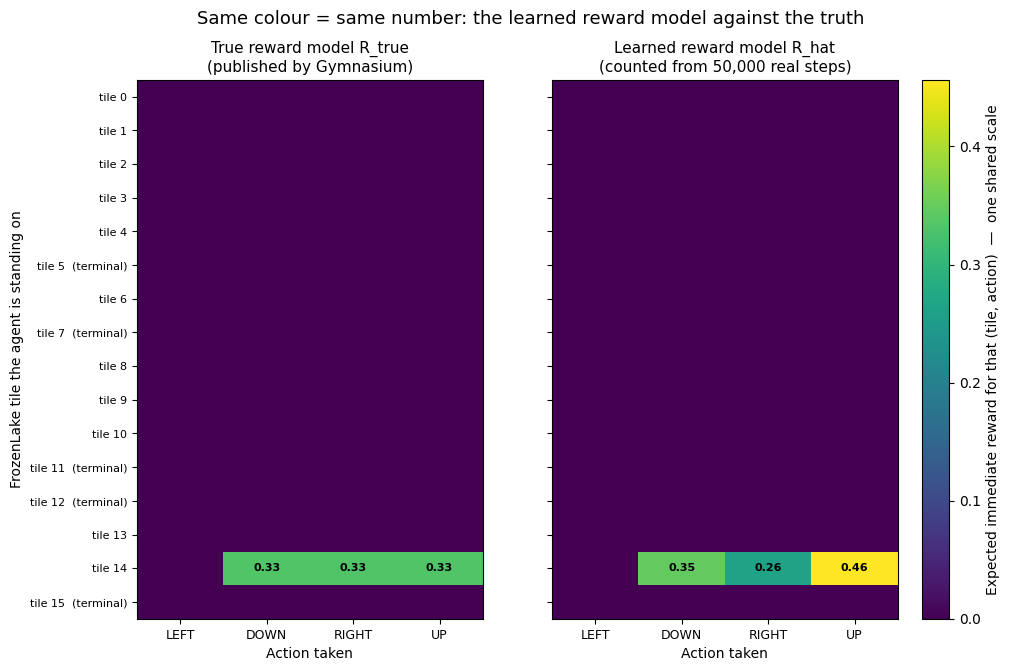

Reward exists on exactly one tile in this environment: tile 14, next door to the goal.
  true    R_true[14] : LEFT=0.000  DOWN=0.333  RIGHT=0.333  UP=0.333
  learned R_hat [14] : LEFT=0.000  DOWN=0.347  RIGHT=0.263  UP=0.457
  tries the agent got on that tile  : LEFT=83  DOWN=95  RIGHT=95  UP=92

Largest disagreement anywhere in the table: 0.123, at tile 14 / UP (true 0.333 vs learned 0.457).
On a shared scale that gap is 27% of the colourbar, so it is visible. On two independent scales it would have been invisible.

Rows for tiles [5, 7, 11, 12, 15] are blank in BOTH panels: an episode ENDS there, so the
agent never takes an action from them and the learned model has nothing to put in.


In [4]:
# ONE honest figure: the learned reward model against the true one.
# WHY the shared scale matters MORE than the plot: if each panel were auto-scaled to its own
# maximum, the biggest cell in each would come out the same bright yellow - and a student
# reading left to right would conclude the learned model had matched the truth. It has not.
# Two grids that are meant to be COMPARED must be drawn against ONE ruler, or the picture
# says the opposite of what the lesson says.

import numpy as np
import matplotlib.pyplot as plt

ACTION_NAMES = ["LEFT", "DOWN", "RIGHT", "UP"]      # FrozenLake's action order, 0..3

# ONE ruler for BOTH panels: the extremes are taken across the two tables together.
vmin = float(min(R_true.min(), R_hat.min()))
vmax = float(max(R_true.max(), R_hat.max()))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 7.0))
panels = [("True reward model R_true\n(published by Gymnasium)", R_true),
          (f"Learned reward model R_hat\n(counted from {budgets[-1]:,} real steps)", R_hat)]

for panel_index, (ax, (panel_title, table)) in enumerate(zip(axes, panels)):
    # vmin/vmax are passed explicitly, so a given colour means the same number in BOTH panels.
    image = ax.imshow(table, cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(panel_title, fontsize=11)
    ax.set_xlabel("Action taken")
    ax.set_xticks(range(len(ACTION_NAMES)))
    ax.set_xticklabels(ACTION_NAMES, fontsize=9)
    ax.set_yticks(range(N_STATES))
    # Both panels have the SAME 16 rows, so only the left one needs the row names. Labelling
    # the right panel too would just print them on top of the left panel's grid.
    if panel_index == 0:
        # Say on the axis itself which tiles are terminal - those are the rows the agent can
        # never act FROM, so they are the rows no amount of experience can ever fill in.
        ax.set_yticklabels([f"tile {s}" + ("  (terminal)" if s in terminal_states else "")
                            for s in range(N_STATES)], fontsize=8)
    else:
        ax.set_yticklabels([])
    # Print every number on its own cell, so "same colour = same number" is checkable by eye.
    for s in range(N_STATES):
        for a in range(len(ACTION_NAMES)):
            value = table[s, a]
            if value > 0:
                ax.text(a, s, f"{value:.2f}", ha="center", va="center",
                        color="black", fontsize=8, fontweight="bold")

axes[0].set_ylabel("FrozenLake tile the agent is standing on")

# ONE colourbar for both panels - there is only one scale, so there is only one legend.
colour_bar = fig.colorbar(image, ax=axes, fraction=0.035, pad=0.03)
colour_bar.set_label("Expected immediate reward for that (tile, action)  —  one shared scale")

fig.suptitle("Same colour = same number: the learned reward model against the truth",
             fontsize=13)
plt.show()

# --- Say in numbers what the picture shows -------------------------------------------------
# Tile 14 sits next to the goal, and it is the ONLY tile any reward is ever collected from.
goal_neighbour = int(np.argmax(R_true.max(axis=1)))
print(f"Reward exists on exactly one tile in this environment: tile {goal_neighbour}, "
      f"next door to the goal.")
print(f"  true    R_true[{goal_neighbour}] : "
      + "  ".join(f"{name}={R_true[goal_neighbour, a]:.3f}" for a, name in enumerate(ACTION_NAMES)))
print(f"  learned R_hat [{goal_neighbour}] : "
      + "  ".join(f"{name}={R_hat[goal_neighbour, a]:.3f}" for a, name in enumerate(ACTION_NAMES)))
print(f"  tries the agent got on that tile  : "
      + "  ".join(f"{name}={int(visits[goal_neighbour, a])}" for a, name in enumerate(ACTION_NAMES)))

biggest_gap = float(np.abs(R_hat - R_true).max())
worst = np.unravel_index(int(np.argmax(np.abs(R_hat - R_true))), R_true.shape)
print(f"\nLargest disagreement anywhere in the table: {biggest_gap:.3f}, at tile {worst[0]} / "
      f"{ACTION_NAMES[worst[1]]} (true {R_true[worst]:.3f} vs learned {R_hat[worst]:.3f}).")
print(f"On a shared scale that gap is {100 * biggest_gap / max(vmax, 1e-9):.0f}% of the colourbar, "
      f"so it is visible. On two independent scales it would have been invisible.")
print(f"\nRows for tiles {terminal_states} are blank in BOTH panels: an episode ENDS there, so the")
print("agent never takes an action from them and the learned model has nothing to put in.")

### 👁️ Read the figure

- **Both grids are drawn on one shared colour scale, under one shared colourbar.** That is the
  whole point of this figure. Read the same colour in the left panel and the right panel and you
  are reading the same number. Every cell also carries its value in text, so you can check that
  claim rather than trust it.
- **Reward lives on exactly one tile.** Only the row for tile 14 — the square next door to the
  goal — is lit in either panel. Everywhere else the expected immediate reward is genuinely zero,
  in the truth and in the learned model alike. Getting *that* shape right is the learned model's
  real achievement.
- **But the lit cells do not match.** In the true panel the three lit cells are the same colour as
  each other: the ice slides three ways with equal chance, so each is exactly 1/3. In the learned
  panel they are visibly *uneven* — one brighter than 1/3, one dimmer. The exact numbers, and the
  handful of tries each estimate rests on, are printed underneath. After 50,000 real steps the
  agent reached that one tile only a few dozen times per action, and a few dozen samples is not
  enough to pin down a probability.
- **The terminal rows are empty in both panels, and that is not a bug.** Tiles 5, 7, 11, 12 and 15
  are holes and the goal. An episode *ends* there, so the agent never acts from them, so no amount
  of extra experience will ever fill those rows in.

**What it proves:** a learned world model is not "the true model, slightly blurry". It is accurate
in proportion to how often you visited each part of it, and blank where you never went. Had these
two grids been drawn on separate colour scales — each auto-scaled to its own maximum — the
brightest cell in each would have come out the same yellow, and the figure would have told you the
model had matched the truth. It has not. That is the difference between a figure that supports the
lesson and a figure that quietly contradicts it.

## ⚠️ Where this breaks

**The assumption that has to hold:** the learned model is accurate *where the plan will take you*.
Not everywhere — where you will go. And a planner will deliberately go to the places the model likes.

- **Planning amplifies model error.** A greedy plan is a sequence of discrete choices; one wrong
  action in one busy state can cost more than many small probability errors elsewhere. The
  non-monotonic row above (0.634 → 0.576 while the model improved) is that effect, measured.
- **A learned model is only valid where you collected data.** Model error on unvisited state-action
  pairs floors at 0.354 here and never improves, because no amount of extra training reaches rows the
  agent can never act from. The planner does not know which rows those are — it will happily route a
  plan through them.
- **Optimism is the specific failure mode.** If the model wrongly believes an action leads somewhere
  good, the planner will choose it, collect data that... often confirms nothing (because the episode
  ends), and the belief persists. This is why practical model-based methods carry uncertainty
  estimates and plan pessimistically with respect to them.
- **You now have two things that can be wrong.** Model-free RL has one failure surface: the policy.
  Model-based has two, and a bad plan does not tell you which half caused it. Budget for the extra
  debugging.
- **Cheaper alternative:** if the environment's dynamics are already known — a simulator, a physics
  model, a documented transition table — do not *learn* a model. Plan with the real one, using the
  value iteration of Unit 1, and get the 0.732 ceiling immediately. And if environment steps are cheap
  and plentiful, model-free RL avoids the whole model-error problem for the price of more interaction:
  the next lesson measures that trade directly.


## Closing Takeaway

**Teaching takeaway:** Model-based RL learns or uses environment dynamics so the agent can simulate consequences before acting.

**If students remember one idea:** Planning becomes possible when the agent has a workable model of how actions change the world.

**Quick check before moving on:**
- Can you explain the difference between acting from experience only and acting with a learned model?
- Can you describe one advantage and one risk of relying on a world model?

**Bridge to the next step:** This makes it easier to compare model-based and model-free RL directly in the next lesson.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## 🔭 State of the field (2026)

The counting model you just built, DreamerV3 and the 2026 systems share one ambition, and in 2026 it got much
larger: world models are now built to be **entered**. One line of work generates continuous, navigable worlds
with video and sound that a user or an agent moves through (Zhang et al. 2026). Another writes the world model
in language, covering many domains at once, and uses it as the simulator an agent is trained in — built
explicitly because real, resettable environments are the scarce resource (Zuo et al. 2026). The role flipped:
a world model is increasingly the training environment itself, not only a planner's private scratchpad.

Every caution you measured here survives that change and matters more because of it. A learned world is
accurate in proportion to where data was collected and blank where nobody ever went; the planner cannot tell
which rows those are; and model accuracy is not a proxy for policy quality — your own table improved the model
from 0.278 to 0.142 while the plan got worse. Those are exactly the questions to put to a generated
environment, and a 16-state map whose true dynamics are published is the only scale at which you can check them
by hand.

- Zuo, Y., Xiao, Z., Sheng, L. et al. (2026). *Qwen-AgentWorld: Language World Models for General Agents*. arXiv:2606.24597. <https://arxiv.org/abs/2606.24597>
- Zhang, S., Li, Y., Zhuang, J. et al. (2026). *EchoWM: Open and Enterable Omnimodal World Models*. arXiv:2608.23189. <https://arxiv.org/abs/2608.23189>

*Context, not curriculum. The examinable content of this lesson is unchanged; this box says where the field went next.*

## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=12 | term=True | trunc=False

objc[59954]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112e00138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1132fc9c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[59954]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112e00188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1132fca18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[59954]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112dffc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1132fca68). T

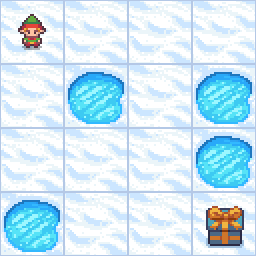

In [5]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Find the shared Course 09 helper (course09_step_viz.py) from ANY folder, and on Google Colab.
# WHAT: look for the helper up the folder chain, then inside a "Course 09" folder on that chain,
#       and only then download it; finally put its folder on Python's import path.
# WHY:  searching only the PARENTS of the working directory breaks the moment you open this
#       notebook from the repository root - there the helper sits in a child folder, not a
#       parent - and on Colab there is no repository at all. This does not care where you
#       started the kernel from.
_HELPER_C9 = "course09_step_viz.py"
_chain_c9 = [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]
_course09 = next((d for d in _chain_c9 if (d / _HELPER_C9).exists()), None)
if _course09 is None:                      # opened from the repo root, or from another course
    _course09 = next((d / "Course 09" for d in _chain_c9
                      if (d / "Course 09" / _HELPER_C9).exists()), None)
if _course09 is None:                      # Google Colab, or a stray copy of this notebook
    import urllib.request
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/"
            "Course%2009/" + _HELPER_C9, _HELPER_C9)
    except Exception as _e:
        raise FileNotFoundError(
            f"Could not find {_HELPER_C9} from this folder, and could not download it either. "
            "Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet and "
            f"re-run this cell. (underlying error: {_e})") from None
    _course09 = pathlib.Path.cwd()

# Put that folder on Python's import path so the helper imports from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
